Knowledge Editing

In [24]:
%%bash
!(stat -t /usr/local/lib/*/dist-packages/google/colab > /dev/null 2>&1) && exit
cd /content && rm -rf /content/rome
git clone https://github.com/kmeng01/rome rome > install.log 2>&1
pip install -r /content/rome/scripts/colab_reqs/rome.txt >> install.log 2>&1
pip install --upgrade google-cloud-storage >> install.log 2>&1

In [25]:
!pip install torch transformers transformer-lens datasets einops accelerate nltk

Download Model

In [26]:
import torch
import torch.nn as nn
import os, matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "gpt2-xl"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

In [27]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model.to(device)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1600)
    (wpe): Embedding(1024, 1600)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-47): 48 x GPT2Block(
        (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=4800, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=1600)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=6400, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=6400)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1600, out_features=50257, bias=False)
)

In [28]:
prompt = "The Eiffel Tower is located in the city of"
inputs = tokenizer(prompt, return_tensors="pt").to(device)
with torch.no_grad():
  out = model.generate(**inputs, max_new_tokens=10)
print(tokenizer.decode(out[0], skip_special_tokens=True))

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Eiffel Tower is located in the city of Paris, France. The tower is the tallest structure


In [29]:
print(out[0, -1])

tensor(4645, device='cuda:0')


Finding the exact probability

In [30]:
with torch.no_grad():
  logits = model(**inputs).logits
  print(logits[0, -1])
  probs = F.softmax(logits[0, -1], dim=-1)

paris_id = tokenizer.encode(" Paris", add_special_tokens=False)[0]
print(f"P(Paris) before edit: {probs[paris_id].item():.4f}")

tensor([ -0.3662,   0.6314,  -3.3538,  ..., -10.4531,  -6.4084,   0.2281],
       device='cuda:0')
P(Paris) before edit: 0.9341


Set up Subject && target tokens

In [31]:
subject = " Eiffel Tower"
target = " Paris"

In [32]:
full_tokens = inputs['input_ids'][0].tolist()
subject_ids = tokenizer.encode(subject, add_special_tokens=False)
subject_ids

[412, 733, 417, 8765]

In [33]:
def find_sublist(lst, sub):
  for i in range(len(lst) - len(sub) + 1):
    if lst[i:i+len(sub)] == sub:
      return list(range(i, i+len(sub)))
  return []

In [34]:
subject_positions = find_sublist(full_tokens, subject_ids)
token_labels = tokenizer.convert_ids_to_tokens(full_tokens)

In [35]:
print(f"Tokens: {token_labels}")
print(f"Subject positions: {subject_positions}")

Tokens: ['The', 'ĠE', 'iff', 'el', 'ĠTower', 'Ġis', 'Ġlocated', 'Ġin', 'Ġthe', 'Ġcity', 'Ġof']
Subject positions: [1, 2, 3, 4]


First Clean Run

In [36]:
n_layers = model.config.n_layer
seq_len = inputs["input_ids"].shape[1]
seq_len

11

In [37]:
clean_hidden = {}

def make_cache_hook(idx):
  def hook(module, input, output):
    tensor_output = output[0] if isinstance(output, tuple) else output
    clean_hidden[idx] = tensor_output[0].detach().clone()
  return hook

hooks = [model.transformer.h[l].register_forward_hook(make_cache_hook(l)) for l in range(n_layers)]

with torch.no_grad():
  clean_out = model(**inputs)
clean_probs = F.softmax(clean_out.logits[0, -1], dim=-1)[paris_id].item()

for h in hooks:
  h.remove()

print(f"Clean P(Paris): {clean_probs:.4f}")

Clean P(Paris): 0.9341


In [38]:
clean_hidden

{0: tensor([[-0.0591,  0.2523, -0.1249,  ...,  0.3887,  0.1889, -0.1542],
         [-1.2982,  0.1010,  0.2463,  ..., -0.2722, -0.4650, -1.0509],
         [-0.1776,  0.1895, -0.5206,  ...,  0.7946, -0.0554,  0.8155],
         ...,
         [-0.2417, -0.1821,  0.1691,  ..., -0.0970,  0.1089, -0.2060],
         [-0.5889, -0.7201,  0.0065,  ...,  0.5036,  0.0707, -0.7994],
         [ 0.0033,  0.2140,  0.1253,  ...,  0.2237, -0.0354,  0.2101]],
        device='cuda:0'),
 1: tensor([[-0.2231,  0.1936, -0.4969,  ...,  0.8918,  0.1726, -0.3148],
         [-1.4798, -0.0906,  0.0783,  ..., -0.5996, -0.4086, -1.4094],
         [-0.4122,  0.5665, -0.2885,  ...,  1.3147, -0.9272,  1.2056],
         ...,
         [-0.5223, -0.3995,  0.1481,  ..., -0.0024,  0.2196,  0.1615],
         [-0.9472, -1.2609,  0.3014,  ...,  0.7927, -0.1187, -1.0399],
         [-0.1303,  0.1212,  0.1333,  ...,  0.3877, -0.1043,  0.3786]],
        device='cuda:0'),
 2: tensor([[-0.1808, -0.0382, -1.0095,  ...,  0.8868,  0.15

Second Pass. Corrupted run

In [39]:
noise_scale = 3 * model.transformer.wte.weight.std().item()
fixed_noise = torch.zeros(1, seq_len, model.config.n_embd, device=device)
for pos in subject_positions:
  fixed_noise[0, pos] = torch.randn(model.config.n_embd, device=device) * noise_scale

def corrupt_emb_hook(module, input, output):
  return output + fixed_noise

h = model.transformer.wte.register_forward_hook(corrupt_emb_hook)
with torch.no_grad():
  corrupt_logits = model(**inputs).logits
corrupt_probs = F.softmax(corrupt_logits[0, -1], dim=-1)[paris_id].item()
h.remove()

print(f"Corrupted P(Paris): {corrupt_probs:.4f}")
print(f"Drop: {clean_probs:.4f} -> {corrupt_probs:.4f}  (corruption is working)")

Corrupted P(Paris): 0.0204
Drop: 0.9341 -> 0.0204  (corruption is working)


Restoration Scan and Heatmap

In [40]:
def make_patch_hook(pos, val):
    def hook(module, input, output):
        if isinstance(output, tuple):
            out = output[0].clone()
            out[0, pos] = val
            return (out,) + output[1:]
        else:
            out = output.clone()
            out[0, pos] = val
            return out
    return hook

In [41]:
scores = torch.zeros(n_layers, seq_len)

for layer_idx in range(n_layers):
  for tok_pos in range(seq_len):
    patch_val = clean_hidden[layer_idx][tok_pos].clone()
    h_corrupt = model.transformer.wte.register_forward_hook(corrupt_emb_hook)
    h_patch = model.transformer.h[layer_idx].register_forward_hook(make_patch_hook(tok_pos, patch_val))

    with torch.no_grad():
      logits_patch = model(**inputs).logits

    h_corrupt.remove()
    h_patch.remove()

    scores[layer_idx, tok_pos] = F.softmax(logits_patch[0, -1], dim=-1)[paris_id].item()

  if layer_idx % 8 == 0:
    print(f"layer {layer_idx}/{n_layers}...")

layer 0/48...
layer 8/48...
layer 16/48...
layer 24/48...
layer 32/48...
layer 40/48...


Plot

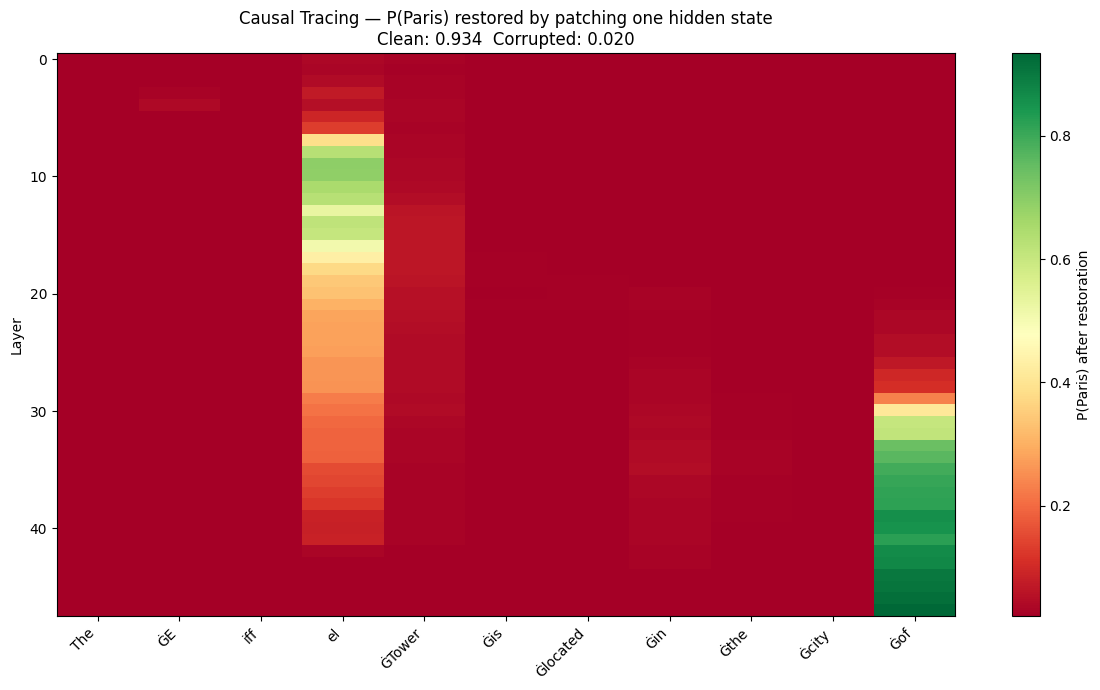


Peak restoration: layer 47, token 'Ġof'


In [42]:
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(scores.cpu().numpy(), aspect='auto', cmap='RdYlGn',
               vmin=corrupt_probs, vmax=clean_probs)
ax.set_xticks(range(seq_len))
ax.set_xticklabels(token_labels, rotation=45, ha='right')
ax.set_ylabel("Layer")
ax.set_title(f'Causal Tracing — P(Paris) restored by patching one hidden state\n'
             f'Clean: {clean_probs:.3f}  Corrupted: {corrupt_probs:.3f}')
plt.colorbar(im, label="P(Paris) after restoration")
plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/trace_heatmap.png", dpi=150)
plt.show()

peak_layer, peak_tok = divmod(scores.argmax().item(), seq_len)
print(f"\nPeak restoration: layer {peak_layer}, token '{token_labels[peak_tok]}'")
